# Temporal organization beyond matched circular covariance

**Development result:** covariance mean 50.0%; p90 means 59.4% (strongest mean readout 71.9%); distributions 46.9%; primary SPI–SPI 100.0%. A subsequently inspected training-ranked single mean reaches **93.8%**, so the apparent advantage over marginal readouts needs qualification. Chance is 50%. Held-release gate: **False**.

This paired Gaussian experiment changes the temporal arrangement of dependence while preserving each realized covariance matrix and every circular cross-correlation function. It tests a specific dependence property, rather than differences between unrelated MTS families. The full p90 mean/distribution baselines are retained: no assumption says they must fail.

For each of eight independent pairs, $x_t=\epsilon_t$ and $y_t=a\epsilon_{\pi(t)}+\sqrt{1-a^2}\eta_t$, with independent standard Gaussian drivers. The permutation $\pi$ swaps adjacent five-sample blocks, producing alternating $+5/-5$ lags. The eight coefficients span .35–.85. Channel labels are randomly permuted and channels empirically standardized. Individual channels before standardization are Gaussian iid; the cross-channel dependence is time-varying. This is not a nonlinear or causal dynamical model.

The paired surrogate multiplies every channel's Fourier coefficient at frequency $f$ by the same random unit phase $e^{i\phi_f}$. Thus $\tilde X_i(f)\tilde X_j(f)^*=X_i(f)X_j(f)^*$ exactly. Covariance and circular auto/cross-correlation follow unchanged. This applies to the global circular definition, not necessarily windowed spectral estimators or correlations that trim the ends. Realized amplitude histograms are not preserved; third/fourth-moment checks are therefore included in the cheap scout.

In the population illustration below, the temporal cross-covariance operator changes from $K=aP$ to $Q^\top KQ$, where $P$ is the lag permutation and $Q$ the shared orthogonal Fourier rotation. Singular values—and hence operator strength—remain unchanged. The location of dependence across time changes; the surrogate is not asserted to be stationary. This follows the principle of constrained [surrogate-data methods](https://arxiv.org/abs/chao-dyn/9909037); the figure illustrates T100, whereas the p90 bank uses M16/T1000.

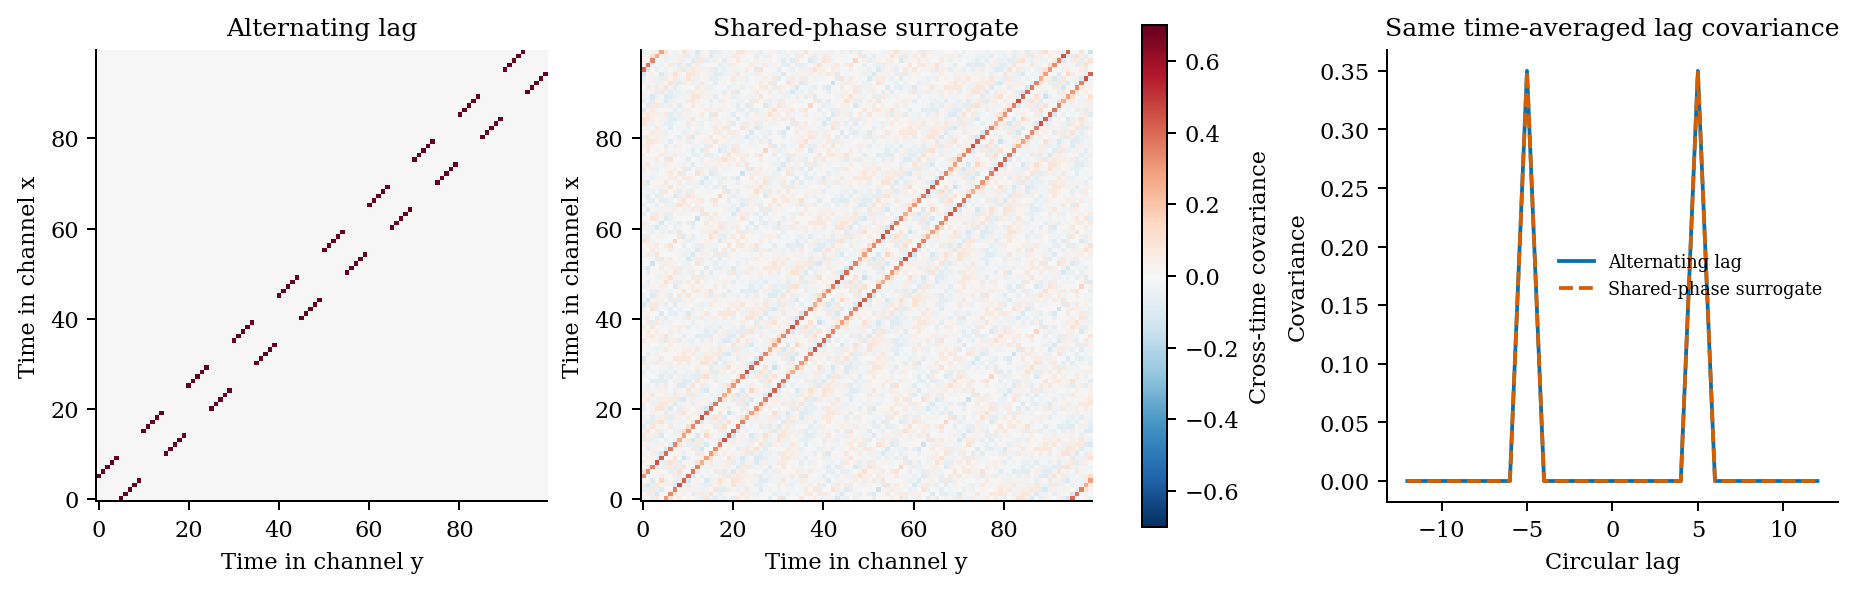

,method,model,BA
0,probe_mean,LogisticRegression,0.65625
1,probe_mean,SVC,0.65625
2,probe_z,LogisticRegression,0.71875
3,probe_z,SVC,0.68750
4,covariance,LogisticRegression,0.50000
5,covariance,SVC,0.50000
6,univariate,LogisticRegression,0.40625
7,univariate,SVC,0.43750


In [1]:
from pathlib import Path
import json,pandas as pd
from IPython.display import display,Image
ROOT=Path.cwd().resolve()
while not (ROOT/'pyproject.toml').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
OUT=ROOT/'results/representation/lag-surrogate-261004'; TARGET=OUT/'development'
display(Image(filename=str(OUT/'figures/mechanism.png')))
display(pd.read_csv(OUT/'probe-metrics.csv'))

Development uses 32 paired training realizations and 16 paired validation realizations, all at M16/T1000. An additional 16 zero-coupling pairs test whether the procedure creates a class signature without dependence. A separate 32-pair held bank remains uncomputed unless every frozen gate passes. The six-probe scout is development evidence, not confirmation. Splits, classifier settings and gates were committed before p90 outcomes.

In [2]:
display(pd.read_csv(TARGET/'metrics.csv').round(3))
display(pd.read_csv(TARGET/'paired.csv').round(3))
a=json.loads((TARGET/'analysis.json').read_text()); display(a['development_gate']); display(a['null_accuracy']); display(pd.read_csv(TARGET/'null-projection-validity.csv'))

,method,n,BA,low,high,chance
0,mean,32,0.594,0.469,0.719,0.5
1,distribution,32,0.469,0.312,0.625,0.5
2,z,32,1.000,1.000,1.000,0.5
3,z_validity,32,0.438,0.281,0.625,0.5
4,b,32,0.500,0.500,0.500,0.5
5,pearson_two,32,0.500,0.500,0.500,0.5
6,z_complete,32,1.000,1.000,1.000,0.5
7,z_standard,32,0.938,0.844,1.000,0.5
8,mean_complete,32,0.594,0.469,0.719,0.5
9,z_shuffled_complete,32,0.531,0.438,0.625,0.5


,comparison,difference,low,high
0,z_complete - b,0.500,0.500,0.500
1,z_complete - b_RBF,0.469,0.344,0.594
2,z_complete - b_full,0.500,0.500,0.500
3,z_complete - b_trees,0.500,0.500,0.500
4,z_complete - distribution,0.531,0.375,0.688
5,z_complete - mean,0.406,0.281,0.531
6,z_complete - mean_RBF,0.375,0.250,0.500
7,z_complete - mean_complete,0.406,0.281,0.531
8,z_complete - mean_full,0.375,0.250,0.469
9,z_complete - mean_trees,0.281,0.156,0.406


{'z_strong': True,
 'means_weak': False,
 'covariance_weak': True,
 'validity_weak': True,
 'shuffle_weak': True,
 'null_weak': True,
 'all_pass': False}

{'mean': 0.5, 'z': 0.5}

,method,mean_imputed_fraction,max_imputed_fraction
0,mean,0.0,0.0
1,z,0.0,0.0


Every feature filter, imputation, scaling and PCA fit uses training data only. Primary $z$ uses training-complete features and centered PCA20/logistic C1; means/distributions use SD scaling, clipping at five SD and PCA20. Full linear/RBF/tree mean controls, standardized $z$, validity-only and independently edge-shuffled $z$ remain visible. Paired bootstrap intervals condition on the training set and chosen construction. Plots show every validation/held point, projected with training-fitted PCA/UMAP (30 neighbors, min_dist .1, seed261003); no embedding setting was selected from the outcome. Marker area follows $\sqrt M$, constant here because every recording has M16. Scalar vertical jitter is display-only.

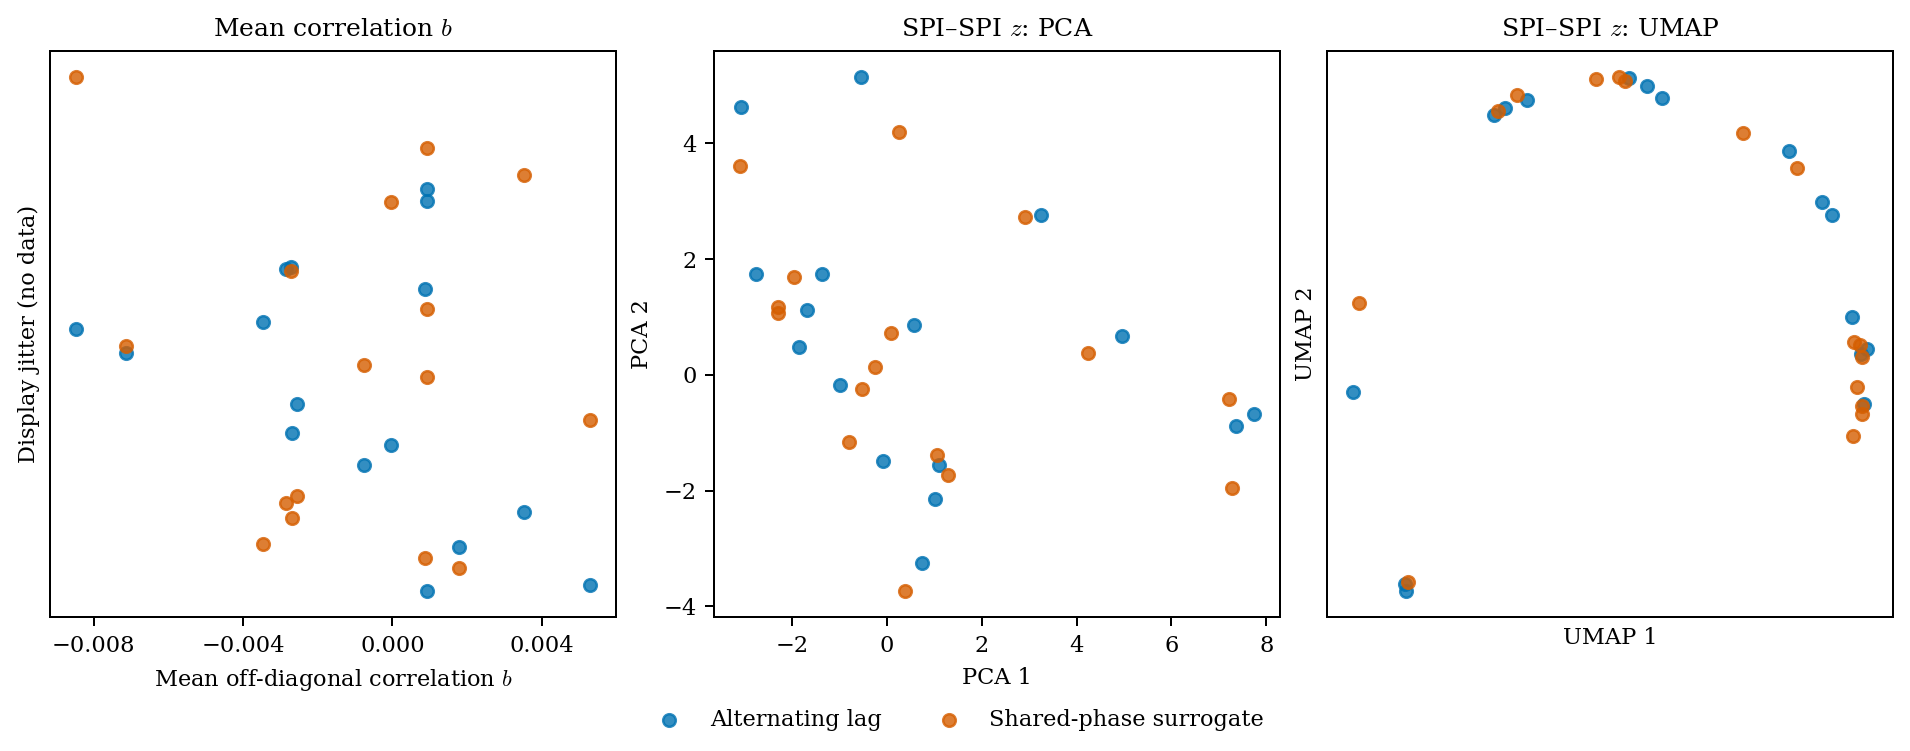

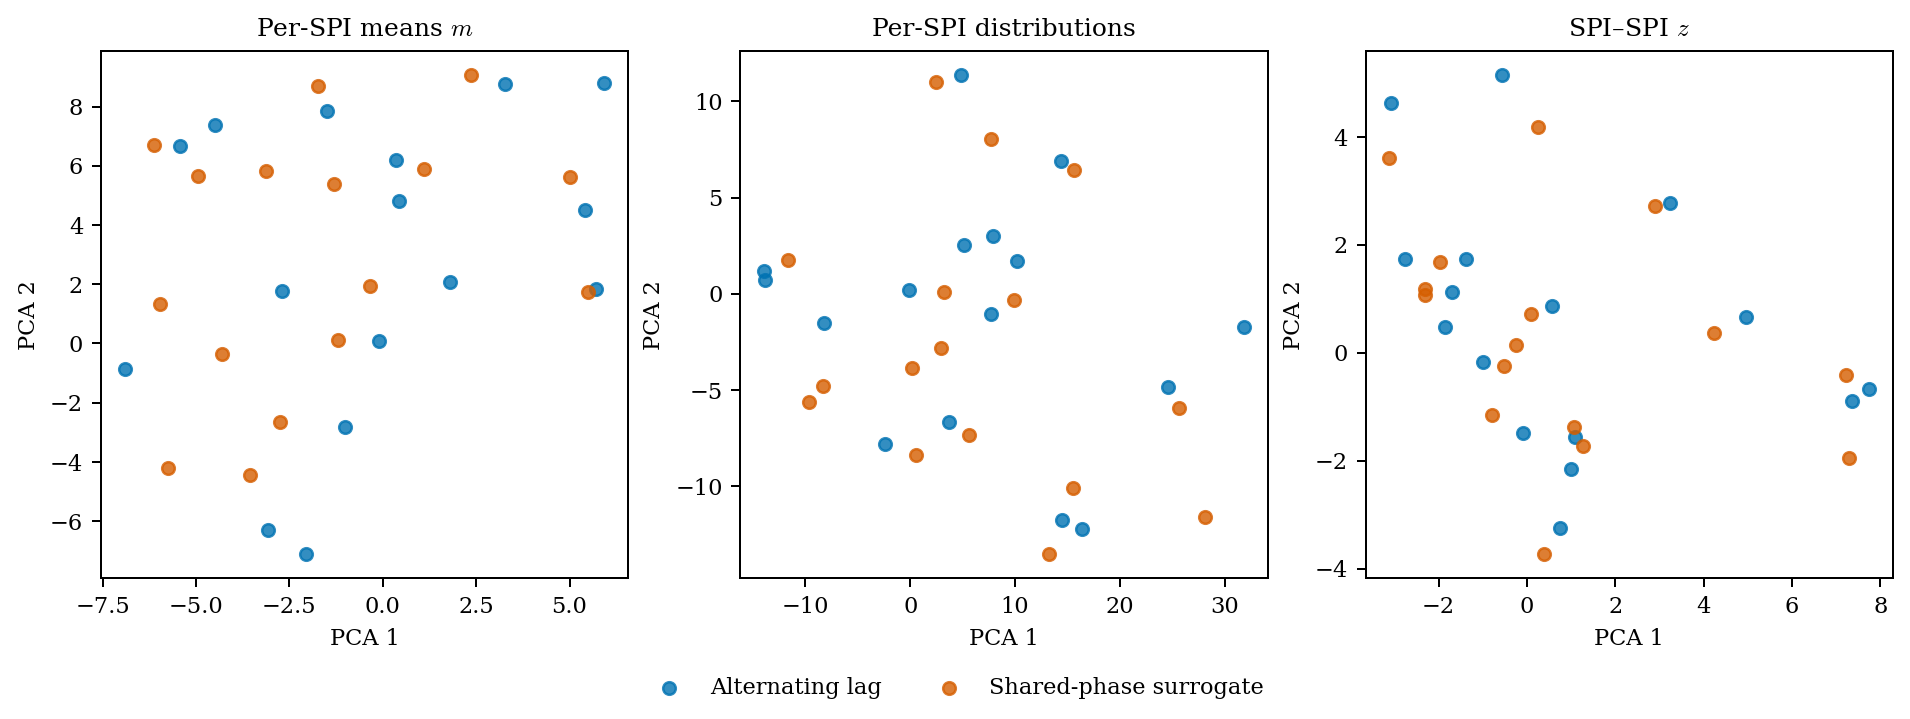

In [3]:
display(Image(filename=str(TARGET/'figures/scalar-vs-z.png')))
display(Image(filename=str(TARGET/'figures/marginal-comparison.png')))

## Stronger mean diagnostic

After the primary development scores, training-ranked mean features revealed a strong lag-5 Kendall signal. Ranking uses only the 64 training recordings (largest absolute standardized class difference); the selected mean is then classified with a one-dimensional logistic model and a decision stump, also fitted only on training. These are exploratory diagnostics inspected after validation outcomes, not independent confirmation. The logistic model scores 93.8% against SPI–SPI 100%, and the paired difference is unresolved. The fixed PCA/UMAP displays are mixed despite perfect classification using 20 components, so this does not establish the desired visual contrast either. The original all-means≤65% gate failed. A proposed separate confirmation was cancelled before submission after this diagnostic; both the original held bank and the subsequently prepared fresh bank remain uncomputed.

,feature,feature_index,selection,model,BA,AUC,z_minus_selected,paired_low,paired_high
0,corr_kendall_tau-5-sq,73,Maximum absolute training standardized differe...,LogisticRegression,0.9375,0.9766,0.0625,0.0,0.1562
1,corr_kendall_tau-5-sq,73,Maximum absolute training standardized differe...,DecisionTreeClassifier,0.9062,0.9766,0.0938,0.0,0.1875


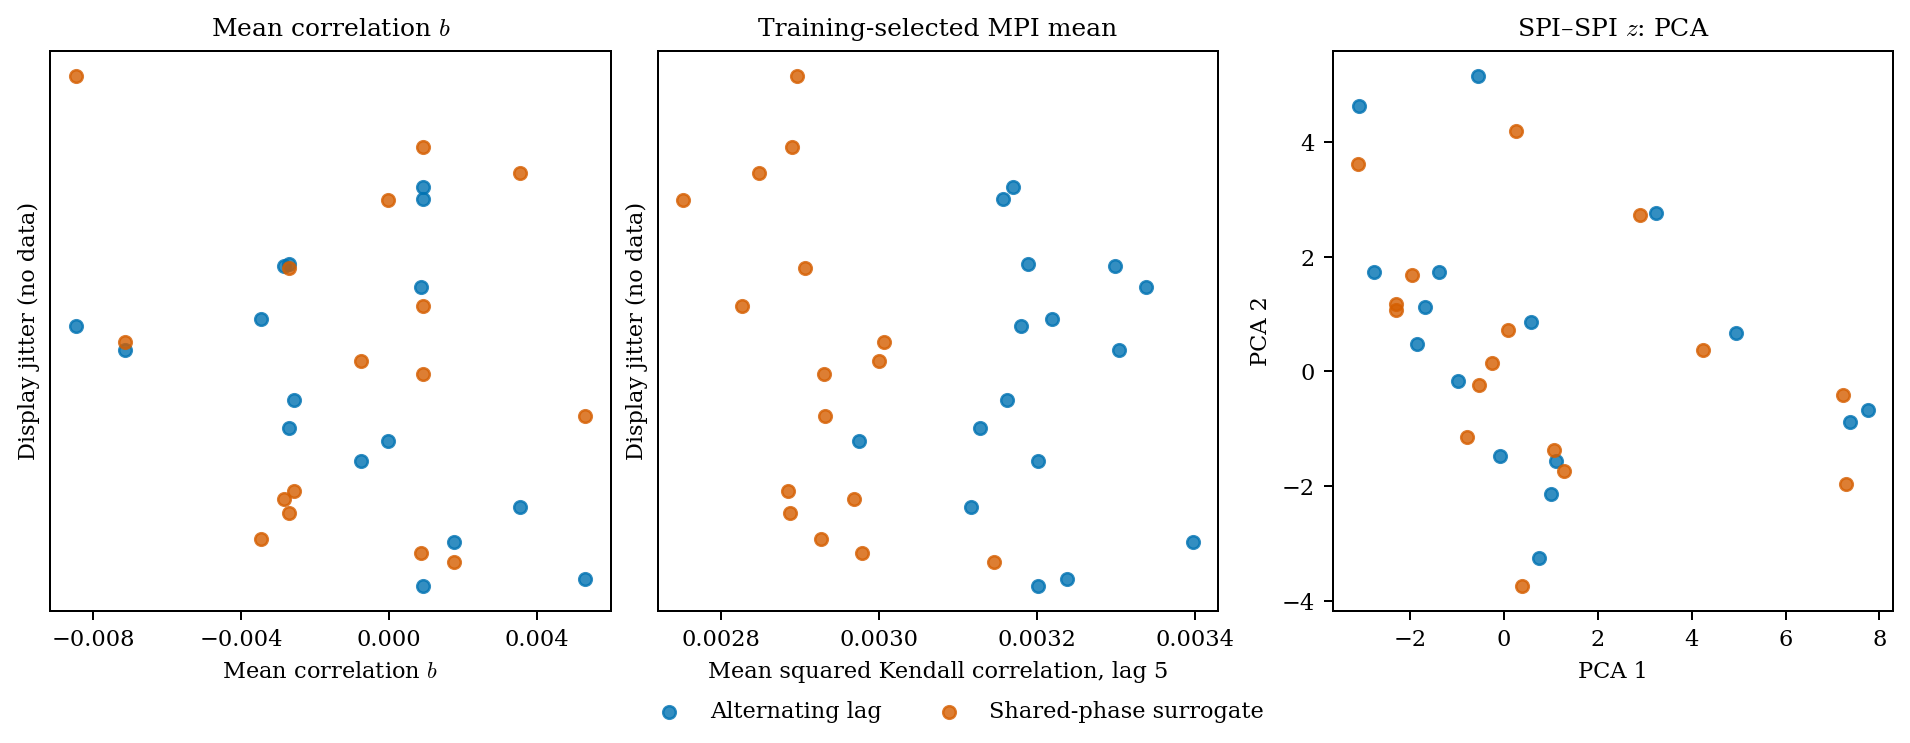

In [4]:
display(pd.read_csv(TARGET/'selected-mean-control.csv').round(4))
display(Image(filename=str(TARGET/'figures/selected-mean-vs-z.png')))

A successful scalar comparison shows information beyond complete global circular second-order summaries in this constructed example. It does not establish that p90 means or distributions are blind to temporal organization, nor that every z coordinate has a unique physical interpretation. Stationary-model and causal interpretations of individual SPIs are not warranted for this time-varying construction. Weakness of the tested mean classifiers would still not establish absence of information. Any failed development gate leaves held SPI computation unreleased; do not tune parameters or classifiers on held outcomes.

In [5]:
display(a['diagnostics'])
display(json.loads((OUT/'execution.json').read_text()))

{'mean': {'selected_features': 264,
  'components': 20,
  'validation_selected_missing_fraction': 0.0},
 'distribution': {'selected_features': 1838,
  'components': 20,
  'validation_selected_missing_fraction': 0.0},
 'z': {'selected_features': 29744,
  'components': 20,
  'validation_selected_missing_fraction': 0.0},
 'z_validity': {'selected_features': 6312,
  'components': 20,
  'validation_selected_missing_fraction': 0.0},
 'b': {'selected_features': 1,
  'components': 1,
  'validation_selected_missing_fraction': 0.0},
 'pearson_two': {'selected_features': 2,
  'components': 2,
  'validation_selected_missing_fraction': 0.0},
 'z_complete': {'selected_features': 29744,
  'components': 20,
  'validation_selected_missing_fraction': 0.0},
 'z_standard': {'selected_features': 29744,
  'components': 20,
  'validation_selected_missing_fraction': 0.0},
 'mean_complete': {'selected_features': 264,
  'components': 20,
  'validation_selected_missing_fraction': 0.0},
 'z_shuffled_complete': {'

{'stage': 'complete: development gate failed; stronger selected-mean diagnostic rules out intended contrast',
 'source_commit': '669a718',
 'source_path': '/scratch/ql44/we2614/mts-spi-study/operations/sources/lag-surrogate-669a718',
 'pyspi_commit': '65317c9c1fd5f12358b8ede09b7576ef001a76dd',
 'raw_sha256': '946e8d6cc048b698b8188857ba70360fde1748dab4df71330c0ae34448cf2fc7',
 'jobs': {'smoke': {'id': '180466254',
   'indices': [1, 2],
   'cpus': 2,
   'mem_GB': 12,
   'walltime': '00:25:00',
   'task_timeout': 1200,
   'outcome': {'exit_status': 0,
    'complete': 2,
    'walltime': '00:05:50',
    'cpu_time': '00:09:35',
    'peak_memory_kb': 6303832}},
  'node': {'id': '180466420',
   'indices': [1, 48],
   'cpus': 48,
   'mem_GB': 190,
   'walltime': '00:20:00',
   'task_timeout': 900,
   'skip_existing': True,
   'outcome': {'complete': 48,
    'exit_status': 0,
    'walltime': '00:06:53',
    'cpu_time': '04:40:29',
    'peak_memory_kb': 56434100}},
  'remaining_development': {'id